In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

# Question 1: Which hour has the highest frequency of crimes?
- Time occurrence stores 24hr time as string -> First two digits will be the hour
- Use value_counts() to find hour. May as well visualize as well.

Crime Occurrence Frequencies (sorted by frequency, descending)
OCC HOUR
12    13663
18    10125
17     9964
20     9579
15     9393
19     9262
16     9224
14     8872
11     8787
0      8728
21     8701
22     8531
13     8474
10     8440
8      7523
23     7419
9      7092
1      5836
6      5621
7      5403
2      4726
3      3943
4      3238
5      3171
Highest frequency of crimes is 13663, at hour 12 



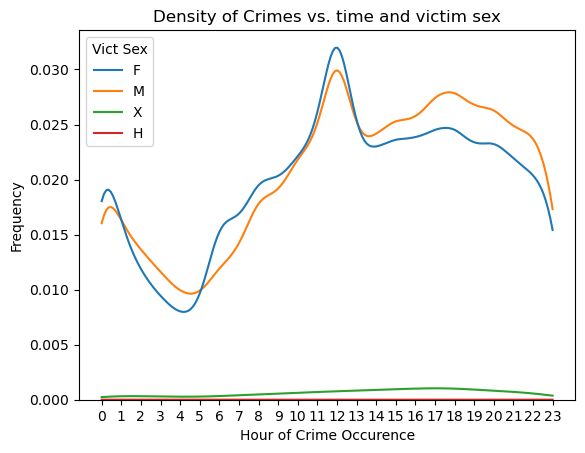

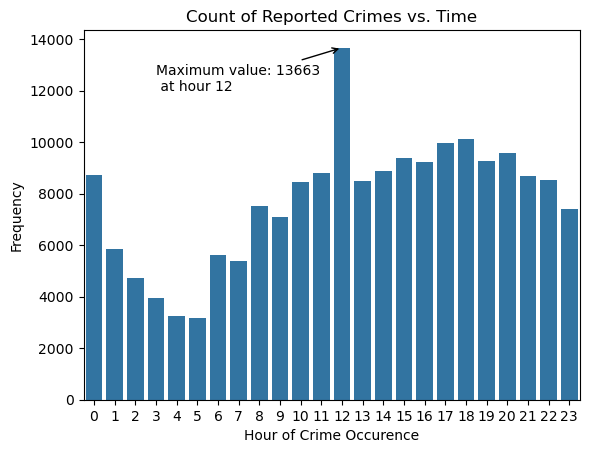

In [12]:
# Slice first two digits of each TIME OCC value, cast to int, save as a new column
crimes["OCC HOUR"] = [int(time[:2]) for time in crimes["TIME OCC"]]

# Frequency table of Occ hours
occ_hour_freqs = crimes["OCC HOUR"].value_counts()
print("Crime Occurrence Frequencies (sorted by frequency, descending)")
print(occ_hour_freqs.to_string())

# Get first item as a tuple
max_hour, max_freq = next(occ_hour_freqs.items())
max_occ_info = f"Highest frequency of crimes is {max_freq}, at hour {max_hour}"
print(max_occ_info,"\n")

# Show a KDE Plot for breakdown by hour and Vict Sex
sns.kdeplot(data=crimes, x="OCC HOUR", hue="Vict Sex", cut=0)
plt.xticks(range(24))
plt.title("Density of Crimes vs. time and victim sex")
plt.xlabel("Hour of Crime Occurence")
plt.ylabel("Frequency")
plt.show()

# Show a countplot for overall frequency
annot_text = f"Maximum value: {max_freq} \n at hour {max_hour}"
ax = sns.countplot(data=crimes, x="OCC HOUR")
ax.annotate(annot_text, xy=(12,max_freq),xytext=(3,12000),arrowprops={"arrowstyle":"->"})
plt.xticks(range(24))
plt.title("Count of Reported Crimes vs. Time")
plt.xlabel("Hour of Crime Occurence")
plt.ylabel("Frequency")
plt.show()

# Assign value to appropriate variable as requested
peak_crime_hour = max_hour

# Question 2: Which area has the largest frequency of night crimes?
- Night crimes are defined as from 10PM (2000) to 3:59am (0359)

Approach:
- Create a "night" filter (occ_hour < 4 or occ_hour>20)
- Filter dataset by night crimes
- Use value_counts()
- May as well create a countplot (area vs. night crime frequency) as well

AREA NAME
Central        4050
Hollywood      3138
77th Street    3099
Southwest      2880
Southeast      2668
Olympic        2637
Newton         2510
Pacific        2403
Rampart        2242
N Hollywood    2218
Wilshire       2101
Northeast      2057
Van Nuys       2031
West Valley    1925
Topanga        1868
Mission        1772
West LA        1743
Devonshire     1723
Harbor         1717
Hollenbeck     1604
Foothill       1498
Name: count, dtype: int64


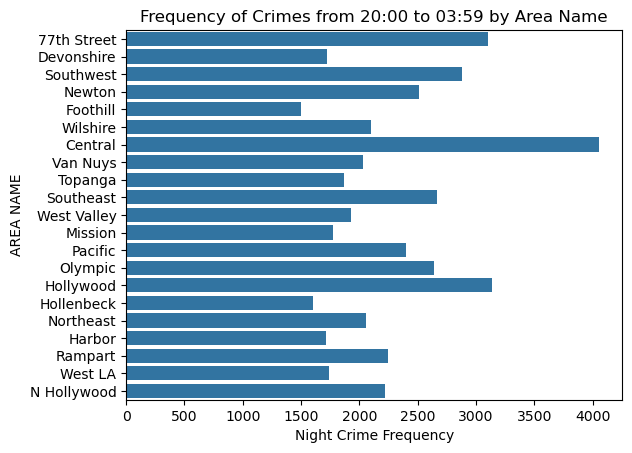

In [6]:
# Create a filter for night crimes using definition give (between 10pm and 3:59am)
night = [np.logical_or(s<4, s>20) for s in crimes["OCC HOUR"]]

# Create a new dataframe of just the night crimes
night_crimes = crimes[night]

# Create a frequency table of value_counts for area names in the night_crimes dataset
night_crime_location_freqs = night_crimes["AREA NAME"].value_counts()
print(night_crime_location_freqs)

# Save index of the most frequent location
peak_night_crime_location = night_crime_location_freqs.index[0]

# Create a countplot to visualize the distribution
sns.countplot(data=night_crimes, y="AREA NAME")
plt.xlabel("Night Crime Frequency")
plt.title("Frequency of Crimes from 20:00 to 03:59 by Area Name")
plt.show()

# Question 3: Number of crimes committed against victims of different age groups
- Create labels and corresponding bins
- Use pd.cut to add age category
- use value counts to find the frequency of crimes against each age group
- Visualize as well

In [7]:
#Define labels and bins
labels = ["0-17", "18-25", "26-34", "35-44", "45-54", "55-64", "65+"]
bins = [0,17,25,34,44,54,64,crimes["Vict Age"].max()]
# Add category column
crimes["Vict Age Category"] = pd.cut(crimes["Vict Age"], labels=labels, bins=bins)
# Check dataframe
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION,OCC HOUR,Vict Age Category
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV,11,26-34
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST,16,55-64
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT,12,26-34
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV,6,35-44
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST,9,65+


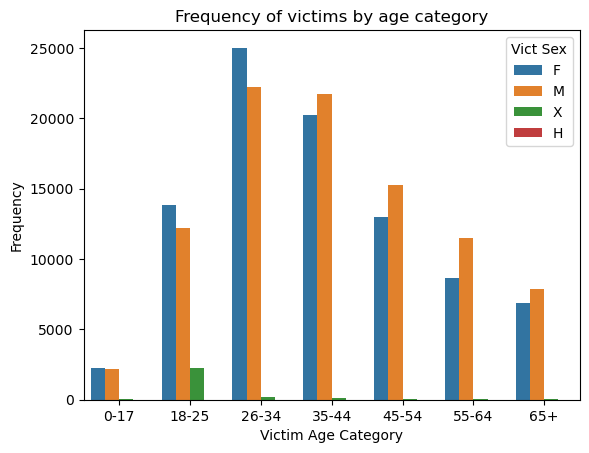

In [11]:
# Find frequency by category
victim_ages = crimes["Vict Age Category"].value_counts()
victim_ages = victim_ages.reindex(labels)
sns.countplot(data = crimes, x = "Vict Age Category", hue="Vict Sex")
plt.title("Frequency of victims by age category")
plt.xlabel("Victim Age Category")
plt.ylabel("Frequency")
plt.show()